#### Loading packages

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import itertools


#### Setting root directory path

In [3]:
ROOT = r'C:\Users\PC_DS_ECON_5\Desktop\data-analytics-python'


#### Data source used: NLSY97

The NLSY97 is a `longitudinal` (i.e. `panel`) survey of individuals born between 1980 and 1984 (country: U.S.). The first round of data collection took place in 1997 and was followed by additional survey rounds every one or two years.

**Selected data**

The selected data `all_jobs` contains information (earnings, tenure, hours, occupation, industry) on all jobs besides demographic, background, and educational variables for all survey rounds between 1998 and 2023.


#### Loading data

Reminder 1 : We need the `pyarrow` package to import a `.parquet` datafile.
Reminder 2 : Verify the that `ROOT` directory is correctly set and the file is indeed the `data` folder.

In [4]:
all_jobs = pd.read_parquet(ROOT + '/data/nlsy97_all_jobs.parquet')

Unit of observation:
 - `person_id` $\times$ `year` $\times$ `rank` (job rank within each individual-year)
 - `person_id` $\times$ `year` $\times$ `job_id`

#### Objective: predicting log hourly pay

In the previous sessions, our main focus was on interpreting regression coefficients.

We now turn to an illustration of prediction.

One of the main strengths of linear regression is that it provides interpretable estimates of the relationship between variables. At the same time, it is flexible enough to be used for prediction. Regressors and outcome variables can be transformed and combined in many different ways while the model remains linear, provided that it is linear in the parameters.

Our objective will be to predict log hourly pay. Although this prediction task is somewhat artificial, it provides a convenient setting for introducing the concepts of training and test data, overfitting, and cross-validation.

What variables should we use?

To predict log hourly pay, we consider the following set of explanatory variables:

 - `educ_cat`: educational attainment (categorical)
 - `ASVAB_pct`: percentile rank on the ASVAB test (1997)
 - `cumulative_observed_work_weeks`: proxy for accumulated work experience
 - `tenure_in_weeks`: tenure in the current job
 - `occupation_group`: occupation category
 - `industry_group`: industry category
 - `year`
 - `age`
 - `feduc_res_cat`: father's educational attainment
 - `meduc_res_cat`: mother's educational attainment


Defining the outcome variable and keeping only observations with non-missing positive hourly pay and non-missing regressors:


In [7]:
df = all_jobs.copy()
df['log_hpay'] = pd.NA
# log hourly pay is defined only for observations with positive hourly pay
valid = df['hpay'] > 0 
df.loc[valid, 'log_hpay'] = np.log(df.loc[valid, 'hpay'])
df = df.convert_dtypes()
all_jobs = df.copy()

Keeping only relevant variables:

In [8]:
df = all_jobs.copy()
cols = ['person_id', 'year', 'rank', 'job_id', 'log_hpay', 'educ_cat', 'ASVAB_pct', 
        'cumulative_observed_work_weeks', 'tenure_in_weeks', 
        'occupation_group', 'industry_group', 'age',
        'feduc_res_cat', 'meduc_res_cat']
df = df[cols].copy()
df = df.dropna().reset_index(drop=True)
selected = df.copy()

#### Assessing prediction quality

The objective is to estimate a prediction function $\widehat{f}$ that predicts log hourly pay from a set of regressors:

$$
\widehat{\log(hpay)} = \widehat{f}(Regressors)
$$

To assess the quality of the prediction, we use the root mean squared error (RMSE):
$$
RMSE(\widehat{f}, S) =
\sqrt{
\frac{1}{N_S}
\sum_{i \in S}
\left(
\log(hpay_i)-\widehat{f}(Regressors_i)
\right)^2
},
$$

where $S$ denotes the sample on which the prediction error is evaluated.

#### Train-test split

To evaluate the predictive performance of the model, we split the data into two samples:

 - Training sample (or estimation sample)
    - used to estimate the prediction function $\widehat{f}$ using OLS:
        $$
        \widehat{f} = \arg\min_{\widetilde{f}}
        RMSE(\widetilde{f}, \text{Train}).
        $$ 
    - equivalently, OLS minimizes the mean squared error, which yields the same prediction function because the square root is a monotonic transformation.
 - Test sample
    - not used to estimate the prediction function;
    - after estimating $\widehat{f}$, we evaluate its predictive performance on the test sample:
        $$
        RMSE(\widehat{f}, \text{Test});
        $$
       - this measures how well the prediction function generalizes to observations that were not used for estimation.

Since the data contain multiple observations for the same individual, we perform the split at the level of individuals (`person_id`), rather than individual observations:

 - 80% of individuals $\longrightarrow$ training sample
 - 20% of individuals $\longrightarrow$ test sample

As a result, all observations belonging to the same individual are assigned to the same sample.

In [10]:
df = selected.copy()

# all unique person identifiers
df = df[['person_id']].drop_duplicates().reset_index(drop=True).copy()
# count the number of unique person identifiers
N = df.shape[0]
# about 20% of individuals --> test sample
# size of the test smaple
# rounding up to the nearest integer
N_test = np.ceil(0.2 * N).astype(int)
# remaining individuals --> training sample
N_train = N - N_test

# np random number generator
rng = np.random.default_rng(7925367)
# list with N_test items of 'Test' and N_train items of 'Train' 
labels = ['Test'] * N_test + ['Train'] * N_train  

# randomly change the order of the Test/Train labels 
labels = rng.permutation(labels)

# define variable pred_sample
df['pred_sample'] = labels

# merging it with the original data
selected1 = pd.merge(left=selected,
                     right=df,
                     on='person_id',
                     how='left')




In [15]:
train_sample = selected1.loc[selected1['pred_sample'].eq('Train'),:].reset_index(drop=True).copy()
test_sample = selected1.loc[selected1['pred_sample'].eq('Test'),:].reset_index(drop=True).copy()

# progressively include regressors
regressors_all = ['educ_cat', 'ASVAB_pct', 'cumulative_observed_work_weeks', 'tenure_in_weeks', 'occupation_group', 
                  'industry_group', 'year', 'age', 'feduc_res_cat', 'meduc_res_cat', 'educ_cat * occupation_group', 
                  'educ_cat * industry_group', 'feduc_res_cat * occupation_group', 'meduc_res_cat * occupation_group']
M = len(regressors_all)
formula = [pd.NA] * M 
test_rmse = [pd.NA] * M
train_rmse = [pd.NA] * M
n_coef = [pd.NA] * M

# for each position i in the list of all possible regressors
for i in range(0,M):
    print(i)
    # select the regressors up to position (i+1)
    regressors = regressors_all[:(i+1)]
    # define the corresponding formula
    formula[i] = 'log_hpay ~ ' + ' + '.join(regressors)
    # estimating the prediction function using the training sample
    train_reg = smf.ols(formula=formula[i], data=train_sample).fit()
    # calculate the root mean squared error for the training sample
    train_rmse[i] = np.sqrt((np.square(train_sample['log_hpay'] - train_reg.predict(train_sample))).mean())
    # calculate the root mean squared error for the test sample 
    test_rmse[i] = np.sqrt((np.square(test_sample['log_hpay'] - train_reg.predict(test_sample))).mean())
    # saving the number of coefficients (number of parameters)
    n_coef[i] = train_reg.params.shape[0]


0
1
2
3
4
5
6
7
8
9
10
11
12
13


In [16]:
results1 = pd.DataFrame({'formula': formula,
                        'n_coef': n_coef,
                        'train_rmse': train_rmse,
                        'test_rmse': test_rmse})

results1


,formula,n_coef,train_rmse,test_rmse
0,log_hpay ~ educ_cat,4,0.688975,0.705702
1,log_hpay ~ educ_cat + ASVAB_pct,5,0.687282,0.704605
2,log_hpay ~ educ_cat + ASVAB_pct + cumulative_o...,6,0.609700,0.621838
3,log_hpay ~ educ_cat + ASVAB_pct + cumulative_o...,7,0.607900,0.620079
4,log_hpay ~ educ_cat + ASVAB_pct + cumulative_o...,39,0.566527,0.580292
5,log_hpay ~ educ_cat + ASVAB_pct + cumulative_o...,56,0.559830,0.575140
6,log_hpay ~ educ_cat + ASVAB_pct + cumulative_o...,57,0.555993,0.571696
7,log_hpay ~ educ_cat + ASVAB_pct + cumulative_o...,58,0.555934,0.571772
8,log_hpay ~ educ_cat + ASVAB_pct + cumulative_o...,61,0.555727,0.571621
9,log_hpay ~ educ_cat + ASVAB_pct + cumulative_o...,64,0.555656,0.571632


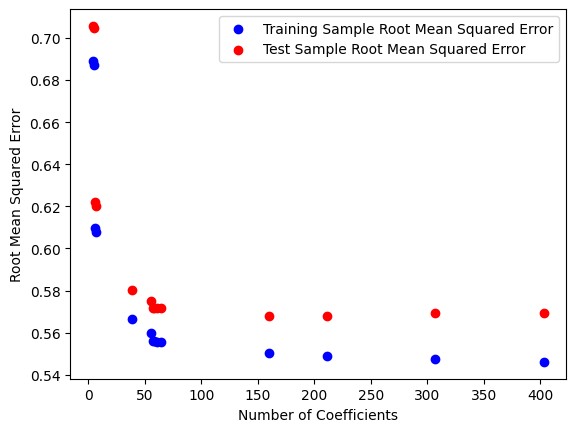

In [17]:


fig, ax = plt.subplots()
# scatter plot: root mean squared error against the number of coefficients
# separately for the train and test samples
ax.scatter(x=results1['n_coef'],y=results1['train_rmse'],c='blue',label='Training Sample Root Mean Squared Error')
ax.scatter(x=results1['n_coef'],y=results1['test_rmse'],c='red',label='Test Sample Root Mean Squared Error')
ax.set_xlabel('Number of Coefficients')
ax.set_ylabel('Root Mean Squared Error')
ax.legend()


#### Cross-Validation

The results obtained from a single train-test split may depend on the particular random split that was chosen.

To reduce this source of randomness, we can use **5-fold cross-validation**.

First, randomly split the full sample into five equally sized parts, called **folds**.

Then repeat the following procedure five times:

- use one fold (20% of the data) as the **test sample**;
- use the remaining four folds (80% of the data) as the **training sample**;
- estimate the model on the training sample;
- compute the test RMSE on the test sample.

Finally, average the five test RMSE values. This average is the **cross-validation RMSE**.

In [ ]:
df = selected.copy()
df = df[['person_id']].drop_duplicates().reset_index(drop=True).copy()

N = df.shape[0]
N1 = np.ceil(0.2 * N).astype(int)
N2 = np.floor(0.2 * N).astype(int)
N3 = np.ceil(0.2 * N).astype(int)
N4 = np.floor(0.2 * N).astype(int)
N5 = N - N1 - N2 - N3 - N4

rng = np.random.default_rng(7925367)

labels = ['Test1'] * N1 + ['Test2'] * N2 + ['Test3'] * N3 + ['Test4'] * N4 + ['Test5'] * N5  

labels = rng.permutation(labels)

df['pred_sample'] = labels

selected2 = pd.merge(left=selected,
                     right=df,
                     on='person_id',
                     how='left')


In [ ]:

regressors_all = ['educ_cat', 'ASVAB_pct', 'cumulative_observed_work_weeks', 'tenure_in_weeks', 'occupation_group', 
                  'industry_group', 'year', 'age', 'feduc_res_cat', 'meduc_res_cat', 'educ_cat * occupation_group', 
                  'educ_cat * industry_group', 'feduc_res_cat * occupation_group', 'meduc_res_cat * occupation_group']
M = len(regressors_all)
splits = range(1,6)
models = range(M)

results2 = pd.DataFrame(itertools.product(splits, models), columns=['split', 'model'])
for varname in ['formula', 'test_rmse', 'train_rmse', 'n_coef']:
    results2[varname] = pd.NA
results2 = results2.convert_dtypes()

for i in models:
    print(i)
    regressors = regressors_all[:(i+1)]
    formula = 'log_hpay ~ ' + ' + '.join(regressors)
    mask = results2['model'].eq(i)
    results2.loc[mask,'formula'] = formula
    for s in splits:
        mask = results2['model'].eq(i) & results2['split'].eq(s)
        train_sample = selected2.loc[selected2['pred_sample'].ne('Test' + str(s)),:].reset_index(drop=True).copy()
        test_sample = selected2.loc[selected2['pred_sample'].eq('Test' + str(s)),:].reset_index(drop=True).copy()
        train_reg = smf.ols(formula=formula, data=train_sample).fit()
        results2.loc[mask, 'train_rmse'] = np.sqrt((np.square(train_sample['log_hpay'] - train_reg.predict(train_sample))).mean())
        results2.loc[mask, 'test_rmse'] = np.sqrt((np.square(test_sample['log_hpay'] - train_reg.predict(test_sample))).mean())
        results2.loc[mask, 'n_coef'] = train_reg.params.shape[0]



In [ ]:
results2_avg = (
    results2
        .groupby('formula')
        .agg(mean_test_rmse = ('test_rmse', 'mean'), mean_train_rmse = ('train_rmse', 'mean'), n_coef = ('n_coef', 'mean'))
        .reset_index()
        .convert_dtypes()
        .copy()
)
results2_avg 


In [ ]:
fig, ax = plt.subplots()

ax.scatter(x=results2_avg['n_coef'], y=results2_avg['mean_train_rmse'], c='blue', marker='D', label='Average Training RMSE')

ax.scatter(x=results2_avg['n_coef'], y=results2_avg['mean_test_rmse'], c='red', marker='x', label='5-fold Cross-Validation RMSE')

ax.set_xlabel('Number of coefficients')
ax.set_ylabel('Root Mean Squared Error')
ax.legend()

As we increase model complexity, the training RMSE always decreases. The cross-validation RMSE also decreases initially, indicating that the additional variables improve prediction. Beyond a certain point, however, the cross-validation RMSE starts to increase while the training RMSE continues to decrease. This divergence is evidence of overfitting.